# Kerr-Newman Ray Tracer
GPU-accelerated null geodesics + Novikov–Thorne disk in one file.

In [1]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Dropdown, IntSlider

try:
    print('Initializing GPU...')
    cp.cuda.Device(0).use()
    props = cp.cuda.runtime.getDeviceProperties(0)
    name = props["name"].decode() if isinstance(props["name"], bytes) else props["name"]
    print(f"Successfully loaded GPU: {name}")
except Exception as e:
    print("Failed to initialize GPU. Falling back to CPU.")
    print(f"Error: {e}")
    cp = np  # Fallback to NumPy if CuPy is not available


Initializing GPU...
Successfully loaded GPU: NVIDIA GeForce RTX 3090


## 2. Rigorous Mathematical Derivations
The simulation is built from first principles. The core components are:

1. **The Kerr-Newman Metric**: Describes the spacetime geometry around a rotating, charged black hole.
2. **Null Geodesic Equations**: The paths of photons are null geodesics, which we solve using a Hamiltonian formulation.
3. **Numerical Integration**: We use a state-of-the-art 8th-order symplectic integrator (Kahan-Li) with a Sundman time transformation to ensure stability and accuracy, especially near the event horizon.
4. **Accretion Disk Model**: A semi-analytic Novikov-Thorne thin disk model provides the source of light, including relativistic effects like Doppler boosting and gravitational redshift.

### Kerr-Newman Metric
The line element in Boyer-Lindquist coordinates (with $M=1$):

$$ds^2 = -\left(1 - \frac{2r - Q^2}{\Sigma}\right)dt^2 + \frac{2a(2r - Q^2)\sin^2\theta}{\Sigma}\,dt\,d\phi + \frac{\Sigma}{\Delta}\,dr^2 + \Sigma\,d\theta^2 + \sin^2\theta\left(r^2 + a^2 + \frac{a^2(2r - Q^2)\sin^2\theta}{\Sigma}\right)d\phi^2,$$

where $\Sigma = r^2 + a^2\cos^2\theta$ and $\Delta = r^2 - 2r + a^2 + Q^2$.

## 3. CUDA Kernels
For performance, all operations (geodesic integration, disk emission, shadow detection) are fused into a single monolithic CUDA kernel. This avoids the overhead of launching multiple kernels per pixel. The code from all necessary `.cu` files in the original repository has been combined. **Please copy the kernel code from the `full_kernel.cu` file into the `FULL_KERNEL` variable**.

In [2]:
# CUDA kernels are now compiled automatically by the nulltracer module.
import nulltracer as nt
nt.compile_all()

AttributeError: Module 'nulltracer' has no attribute 'compile_all' (CuPy may not be installed)

## 4. Rendering Pipeline

In [ ]:
# Rendering functions are now provided by the nulltracer module.
from nulltracer import render_frame


## 5. Interactive Explorer & Post-Processing

In [ ]:
@interact(
    spin=FloatSlider(min=-0.99, max=0.99, step=0.01, value=0.99, description='Spin (a)'),
    charge=FloatSlider(min=0.0, max=0.5, step=0.01, value=0.0, description='Charge (Q)'),
    inclination=IntSlider(min=0, max=90, step=1, value=85, description='Inclination (°)'),
    resolution=IntSlider(min=128, max=1024, step=128, value=256, description='Resolution'),
    bloom=True,
    debug_mode=Dropdown(options=[("Off", 0), ("g-factor", 1), ("Final Coords", 2), ("Disk Temp", 3), ("Disk Radius", 4), ("Impact Param b", 5)], value=0, description="Debug View")
)
def interactive_render(spin, charge, inclination, resolution, bloom, debug_mode):
    img, _ = render_frame(spin, inclination, charge=charge, width=resolution, height=resolution, fov=12.0, debug_mode=debug_mode)
    if bloom:
        from nulltracer import apply_bloom
        img = apply_bloom(img, fov=12.0, width=resolution)
    plt.figure(figsize=(10,10))
    plt.imshow(img)
    plt.title(f'Kerr-Newman: a={spin}, Q={charge}, i={inclination}°')
    plt.axis('off')


interactive(children=(FloatSlider(value=0.99, description='Spin (a)', max=0.99, min=-0.99, step=0.01), FloatSl…

### Airy Disk Bloom (Optional)
The following functions implement a physically-based bloom effect that simulates diffraction in the human eye. This adds to the photorealism of the final image. Note that this part of the notebook requires `scipy`, which is outside the core `cupy`-only constraint for the simulation itself. It is treated as a post-processing step.

In [ ]:
# Bloom post-processing is now integrated into the nulltracer module.
from nulltracer import apply_bloom


## 6. Benchmarks & Export

In [ ]:
def export_image(spin=0.99, charge=0.0, inclination_deg=85, resolution=1024, bloom=True, ext='png', quality=100):
    filename = f'output/KN-BH_a={spin:.2f}_Q={charge:.2f}_i={inclination_deg:03}deg_{resolution}px{"_bloom" if bloom else ""}.{ext}'
    img, _ = render_frame(spin, inclination_deg, charge=charge, width=resolution, height=resolution, fov=12.0)
    if bloom:
        from nulltracer import apply_bloom
        img = apply_bloom(img, fov=12.0, width=resolution)
    plt.imsave(filename, img)
    print(f'✅ Image Saved: {filename} ({img.shape[0]}×{img.shape[1]})')
    return img

export_image()
export_image(spin=0.0, charge=0.0, inclination_deg=0, resolution=1024, bloom=False, quality=75, ext='jpg')
export_image(spin=0.0, charge=0.0, inclination_deg=1, resolution=1024, bloom=False, quality=75, ext='jpg')
export_image(spin=0.0, charge=0.0, inclination_deg=10, resolution=1024, bloom=False, quality=75, ext='jpg')
export_image(spin=0.0, charge=0.0, inclination_deg=89, resolution=1024, bloom=False, quality=75, ext='jpg')
export_image(spin=0.0, charge=0.0, inclination_deg=90, resolution=1024, bloom=False, quality=75, ext='jpg')


✅ Image Saved: output/KN-BH_a=0.99_Q=0.00_i=085deg_1024px_bloom.png (1024×1024)
✅ Image Saved: output/KN-BH_a=0.00_Q=0.00_i=000deg_1024px.jpg (1024×1024)
✅ Image Saved: output/KN-BH_a=0.00_Q=0.00_i=001deg_1024px.jpg (1024×1024)
✅ Image Saved: output/KN-BH_a=0.00_Q=0.00_i=010deg_1024px.jpg (1024×1024)
✅ Image Saved: output/KN-BH_a=0.00_Q=0.00_i=089deg_1024px.jpg (1024×1024)
✅ Image Saved: output/KN-BH_a=0.00_Q=0.00_i=090deg_1024px.jpg (1024×1024)
✅ Image Saved: output/KN-BH_a=0.00_Q=0.00_i=091deg_1024px.jpg (1024×1024)


array([[[ 16,  13,  19],
        [ 16,  13,  19],
        [ 13,  11,  17],
        ...,
        [ 13,  11,  17],
        [ 16,  13,  19],
        [ 16,  13,  19]],

       [[ 16,  13,  19],
        [ 14,  11,  17],
        [148, 126, 102],
        ...,
        [ 14,  12,  17],
        [ 14,  11,  17],
        [ 16,  13,  19]],

       [[ 14,  11,  17],
        [149, 127, 103],
        [236, 202, 159],
        ...,
        [ 14,  12,  18],
        [ 14,  12,  17],
        [ 14,  11,  17]],

       ...,

       [[ 79,  75,  73],
        [ 85,  80,  79],
        [ 92,  87,  85],
        ...,
        [ 63,  57,  53],
        [ 61,  55,  51],
        [ 48,  43,  40]],

       [[ 85,  80,  78],
        [ 76,  71,  70],
        [ 78,  73,  72],
        ...,
        [ 56,  51,  47],
        [ 50,  45,  41],
        [ 58,  53,  49]],

       [[ 87,  82,  80],
        [ 74,  70,  68],
        [ 98,  92,  90],
        ...,
        [ 65,  59,  54],
        [ 70,  63,  59],
        [ 54,  49,  45]]

## 7. Debug Visualizations
This section renders a gallery of the available debug views.

Rendering debug gallery...
Rendering: Standard Render
Rendering: g-factor (Doppler/Redshift)
Rendering: Final Ray Coords
Rendering: Observed Disk Temperature
Rendering: Disk Impact Radius
Rendering: Impact Parameter b


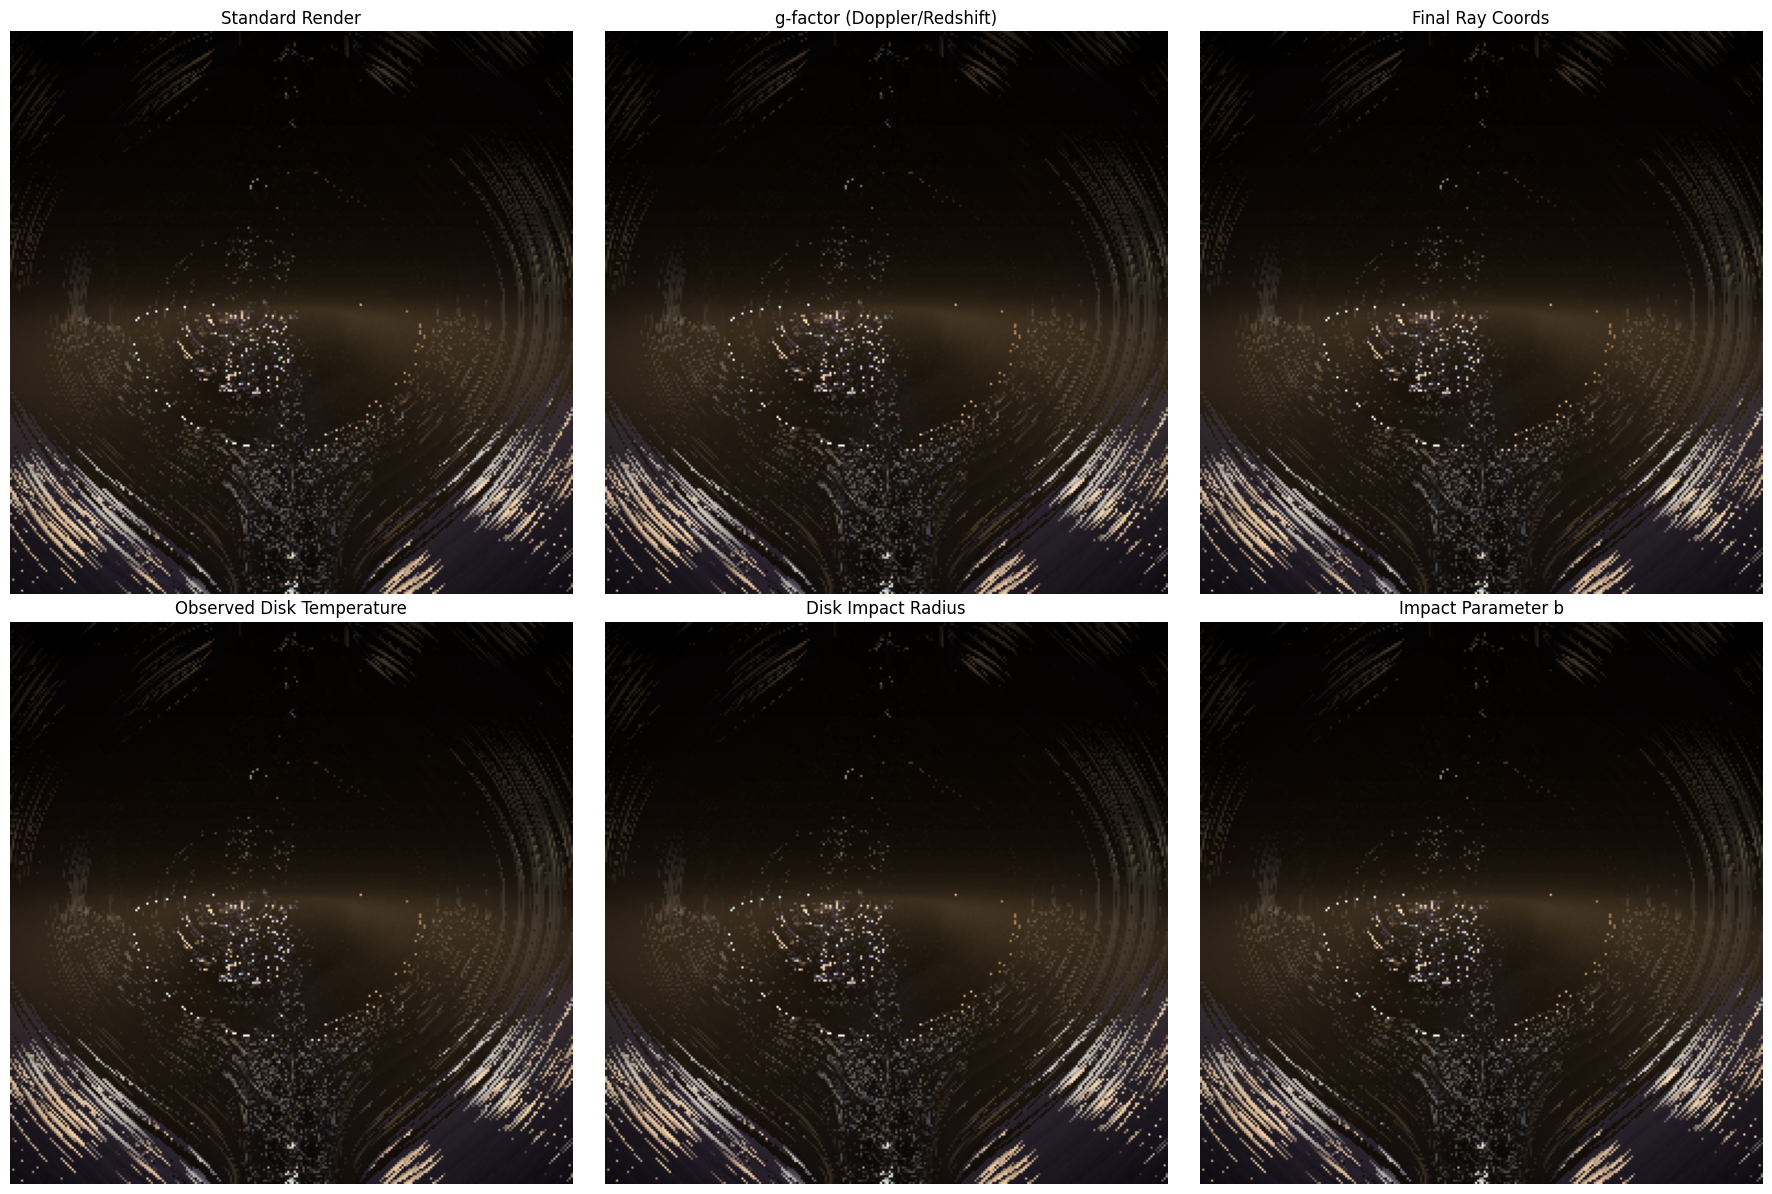

In [ ]:
def plot_debug_gallery():
    print('Rendering debug gallery...')
    params = {'spin': 0.99, 'charge': 0.0, 'inclination_deg': 85, 'width': 256, 'height': 256, 'fov': 12.0}
    debug_modes = {
        'Standard Render': 0,
        'g-factor (Doppler/Redshift)': 1,
        'Final Ray Coords': 2,
        'Observed Disk Temperature': 3,
        'Disk Impact Radius': 4,
        'Impact Parameter b': 5,
    }

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.ravel()

    for i, (title, mode) in enumerate(debug_modes.items()):
        print(f'Rendering: {title}')
        img, _ = render_frame(**params, debug_mode=mode)
        ax = axes[i]
        ax.imshow(img)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

